In [64]:
import pandas as pd
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score 
from sklearn.metrics import ConfusionMatrixDisplay 
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import log_loss 
import numpy as np

In [65]:
matches = pd.read_csv('../data/processed/features_v4.csv')

In [66]:
abs_elo_diff_feature = []
for _, current_match in matches.iterrows():
    abs_elo_diff_feature.append(abs(current_match['EloDiff']))

matches["AbsEloDiff"] = abs_elo_diff_feature

C:\Users\harry\AppData\Local\Temp\ipykernel_26580\1107882626.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  matches["AbsEloDiff"] = abs_elo_diff_feature


In [67]:
features = [ 'PPGDiff', 'GoalAgainstDiffLast5', 'ShotOTDiffLast5', 'GDPerGameDiff', 'GoalsAgainstPerGameDiff', 'EloDiff', 'AbsEloDiff' ]

In [68]:
train = matches[matches['Season'] != '25-26'] 
test = matches[matches['Season'] == '25-26']

In [69]:
X_train = train[features] 
y_train = train['FTR'] 
X_test = test[features] 
y_test = test['FTR']

In [70]:
# model = CalibratedClassifierCV(RandomForestClassifier(
#     n_estimators=300,
#     max_depth=6,
#     min_samples_leaf=10,
#     random_state=42,
#     n_jobs=-1
# ), method='isotonic')

model = CalibratedClassifierCV(RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
), method='sigmoid')

# model = GradientBoostingClassifier()

In [71]:
model.fit(X_train, y_train)

c:\Users\harry\football-analysis\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\harry\football-analysis\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\harry\football-analysis\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\harry\football-analysis\.venv\Lib\site-packages\s

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",RandomForestC...ndom_state=42)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...002A0ED661910>, 

In [72]:
preds = model.predict(X_test)
probs = model.predict_proba(X_test)

print(model.classes_)

c:\Users\harry\football-analysis\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\harry\football-analysis\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\harry\football-analysis\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\harry\football-analysis\.venv\Lib\site-packages\s

['A' 'D' 'H']


In [73]:
accuracy = accuracy_score(y_test, preds) 
print(accuracy)

0.48947368421052634


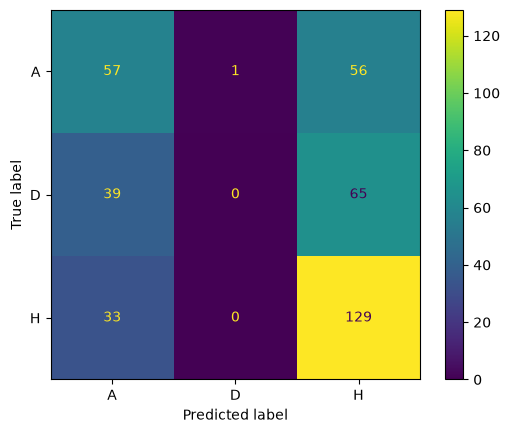

In [74]:
ConfusionMatrixDisplay.from_predictions(y_test, preds)

In [75]:
probs = model.predict_proba(X_test) 
print(model.classes_) 
print(probs[0])

c:\Users\harry\football-analysis\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\harry\football-analysis\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\harry\football-analysis\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\harry\football-analysis\.venv\Lib\site-packages\s

['A' 'D' 'H']
[0.17623955 0.22219271 0.60156774]


c:\Users\harry\football-analysis\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\harry\football-analysis\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\harry\football-analysis\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\harry\football-analysis\.venv\Lib\site-packages\s

In [76]:
results = test[['HomeTeam', 'AwayTeam', 'FTR']].copy() 
results['Predicted'] = preds 
results['AwayProb'] = probs[:, 0] 
results['DrawProb'] = probs[:, 1] 
results['HomeProb'] = probs[:, 2] 
results.head(10)

,HomeTeam,AwayTeam,FTR,Predicted,AwayProb,DrawProb,HomeProb
1520,Liverpool,Bournemouth,H,H,0.176240,0.222193,0.601568
1521,Aston Villa,Newcastle,D,H,0.288644,0.228601,0.482755
1522,Brighton,Fulham,D,H,0.215629,0.188777,0.595594
1523,Sunderland,West Ham,H,H,0.295311,0.236087,0.468602
1524,Tottenham,Burnley,H,H,0.216221,0.243867,0.539913
1525,Wolves,Man City,A,A,0.488386,0.230939,0.280676
1526,Chelsea,Crystal Palace,D,H,0.215316,0.223151,0.561533
1527,Nott'm Forest,Brentford,H,H,0.302693,0.213794,0.483513
1528,Man United,Arsenal,A,A,0.453426,0.246673,0.299901
1529,Leeds,Everton,H,A,0.493627,0.225844,0.280529


In [77]:
importances = np.mean(
    [clf.estimator.feature_importances_
     for clf in model.calibrated_classifiers_],
    axis=0
)

importance = pd.Series(
    importances,
    index=features
).sort_values(ascending=False)

print(importance)

c:\Users\harry\football-analysis\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\harry\football-analysis\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\harry\football-analysis\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\harry\football-analysis\.venv\Lib\site-packages\s

EloDiff                    0.233956
PPGDiff                    0.196079
GDPerGameDiff              0.166236
GoalsAgainstPerGameDiff    0.149313
AbsEloDiff                 0.102446
ShotOTDiffLast5            0.091362
GoalAgainstDiffLast5       0.060608
dtype: float64


c:\Users\harry\football-analysis\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\harry\football-analysis\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\harry\football-analysis\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\harry\football-analysis\.venv\Lib\site-packages\s

In [78]:
print(log_loss(y_test, probs))

1.0316866401478606


In [79]:
results['MaxProb'] = results[['AwayProb','DrawProb','HomeProb']].max(axis=1) 
results['Correct'] = results['Predicted'] == results['FTR'] 
bins = pd.cut(results['MaxProb'], [0.33,0.45,0.55,0.65,0.75,1.0]) 
results.groupby(bins)['Correct'].agg(['mean','count'])

,mean,count
MaxProb,,
"(0.33, 0.45]",0.471429,70
"(0.45, 0.55]",0.400000,140
"(0.55, 0.65]",0.513274,113
"(0.65, 0.75]",0.673077,52
"(0.75, 1.0]",0.800000,5


In [80]:
results['DrawProb'] = probs[:, 1]

In [81]:
results.sort_values('DrawProb', ascending=False)[
    ['HomeTeam', 'AwayTeam', 'FTR', 'Predicted', 'DrawProb']
].head(20)

,HomeTeam,AwayTeam,FTR,Predicted,DrawProb
1856,Wolves,Tottenham,A,D,0.343977
1820,Brentford,Wolves,D,H,0.342477
1709,Sunderland,Man City,D,A,0.333176
1538,Fulham,Man United,D,H,0.325322
1575,Nott'm Forest,Sunderland,A,A,0.313019
1583,Man United,Sunderland,H,A,0.312039
1578,Newcastle,Arsenal,A,A,0.311005
1752,Wolves,Bournemouth,A,A,0.308467
1548,Liverpool,Arsenal,H,A,0.308154
1744,Bournemouth,Liverpool,H,A,0.304546


In [82]:
results['DrawProbBin'] = pd.cut(
    results['DrawProb'],
    [0, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 1]
)

results.groupby('DrawProbBin', observed=True).apply(
    lambda x: pd.Series({
        'ActualDrawRate': (x['FTR'] == 'D').mean(),
        'Count': len(x)
    })
)

,ActualDrawRate,Count
DrawProbBin,,
"(0.0, 0.15]",0.153846,13.0
"(0.15, 0.2]",0.240506,79.0
"(0.2, 0.25]",0.257895,190.0
"(0.25, 0.3]",0.356322,87.0
"(0.3, 0.35]",0.272727,11.0


In [83]:
thresholds = [0.25, 0.27, 0.30, 0.32, 0.35]

for threshold in thresholds:

    threshold_preds = results['Predicted'].copy()

    threshold_preds[results['DrawProb'] >= threshold] = 'D'

    accuracy = (threshold_preds == results['FTR']).mean()

    draws_predicted = (threshold_preds == 'D').sum()
    draws_correct = ((threshold_preds == 'D') & (results['FTR'] == 'D')).sum()

    print(
        f"Threshold: {threshold:.2f} | "
        f"Accuracy: {accuracy:.4f} | "
        f"Draws predicted: {draws_predicted} | "
        f"Correct draws: {draws_correct}"
    )

Threshold: 0.25 | Accuracy: 0.4789 | Draws predicted: 98 | Correct draws: 34
Threshold: 0.27 | Accuracy: 0.4816 | Draws predicted: 49 | Correct draws: 18
Threshold: 0.30 | Accuracy: 0.4868 | Draws predicted: 11 | Correct draws: 3
Threshold: 0.32 | Accuracy: 0.4974 | Draws predicted: 4 | Correct draws: 3
Threshold: 0.35 | Accuracy: 0.4895 | Draws predicted: 1 | Correct draws: 0


In [ ]:
draw_precision = draws_correct / draws_predicted if draws_predicted > 0 else 0

actual_draws = (results['FTR'] == 'D').sum()
draw_recall = draws_correct / actual_draws

print(
    f"Draw precision: {draw_precision:.3f} | "
    f"Draw recall: {draw_recall:.3f}"
)

Draw precision: 0.000 | Draw recall: 0.000


: 